# <font color='black'> Регрессионный анализ социально-экономических процессов, 2025 - 2026 </font>
## <font color='black'> Автокорреляция. Модели с лагированными переменными  </font>
Мы уже рассматривали разные модели для анализа панельных данных. Сегодня продолжим работать с массивом, который Вам уже хорошо знаком, однако обратим внимание на такие сюжеты, как тестирование не одномоментных, а отложенных эффектов объясняющих переменных, а также включение лагированных значений зависимой переменной в модель для того, чтобы в явном виде учесть автокорреляцию. Отчасти воспроизведем сегодня логику анализа TSCS-данных, предложенную в статье Beck N., Katz J. "Modeling Dynamics in Time-Series–Cross-Section Political Economy Data"

Ниже в качестве напоминания продублировано краткое описание данных:

*Источник: Массив данных основан на идее исследования Ehrlich I., Lui F. (1999) Bureaucratic Corruption and Endogenous Economic Growth. The Journal of Political Economy, 107 (6), pp. 270 – 293.*

* country -  Страна
* countrygroup - Страны в датасете разделены на три группы. Первая группа (countrygroup = 1) включает Австралию, Канаду, Японию, Новую Зеландию и США. Вторая группа (countrygroup = 2) включает страны Восточной Европы (Болгария, Хорватия, Чешская Республика, Эстония, Венгрия, Латвия, Польша, Словения, Словакия). В третью группу в основном входят страны Западной Европы
* year - Год. Данные охватывают временной промежуток с 2006 по 2015 год
* pol_stab - Политическая стабильность и отсутствие насилия/терроризма. Отражает склонность к политической нестабильности и/или политически мотивированному насилию, включая терроризм. Значения показателя варьируются от −2.5 до 2.5, причем более высокие значения означают более высокий уровень политической стабильности. Источником данных являются Индикаторы качества государственного управления (WGI). В рамках анализа будем использовать этот показатель в качестве зависимой переменной
* con_cor - Показатель контроля коррупции. Отражает восприятие степени использования государственной власти для личной выгоды, включая как мелкие, так и крупные формы коррупции. Показатель изменяется от −2.5 до 2.5, причем более высокие зна-чения соответствуют более низкому уровню коррупции (т.е. более высокому контролю). Источником данных является WGI. В рамках анализа будем использовать эту переменную в качестве ключевого предиктора
* herfgov_DPI - Индекс концентрации Херфиндаля. В контексте данного исследования он используется для измерения уровня конкуренции между политическими партиями. Шкала варьируется от 0 до 1, где 1 означает отсутствие конкуренции. В рамках анализа будем использовать как контрольную переменную
* govt_consump_WDI - Государственные расходы на конечное потребление (в процентах от ВВП). В рамках анализа будем использовать как контрольную переменную


Подгрузим необходимые библиотеки и откроем уже знакомый Вам массив "reg_lab9.dta".

In [1]:
import pandas as pd
import numpy as np
import math as math
import matplotlib.pyplot as plt
!pip install linearmodels
from linearmodels import PanelOLS
import statsmodels.formula.api as statf
from statsmodels.tsa.stattools import adfuller
import statsmodels.stats.diagnostic as dg
from statsmodels.graphics import tsaplots

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.2 MB/s eta 0:00:00


In [2]:
dta = pd.read_stata("reg_lab9.dta")
dta = dta.dropna()

Рассмотрим динамику зависимой переменной по странам:


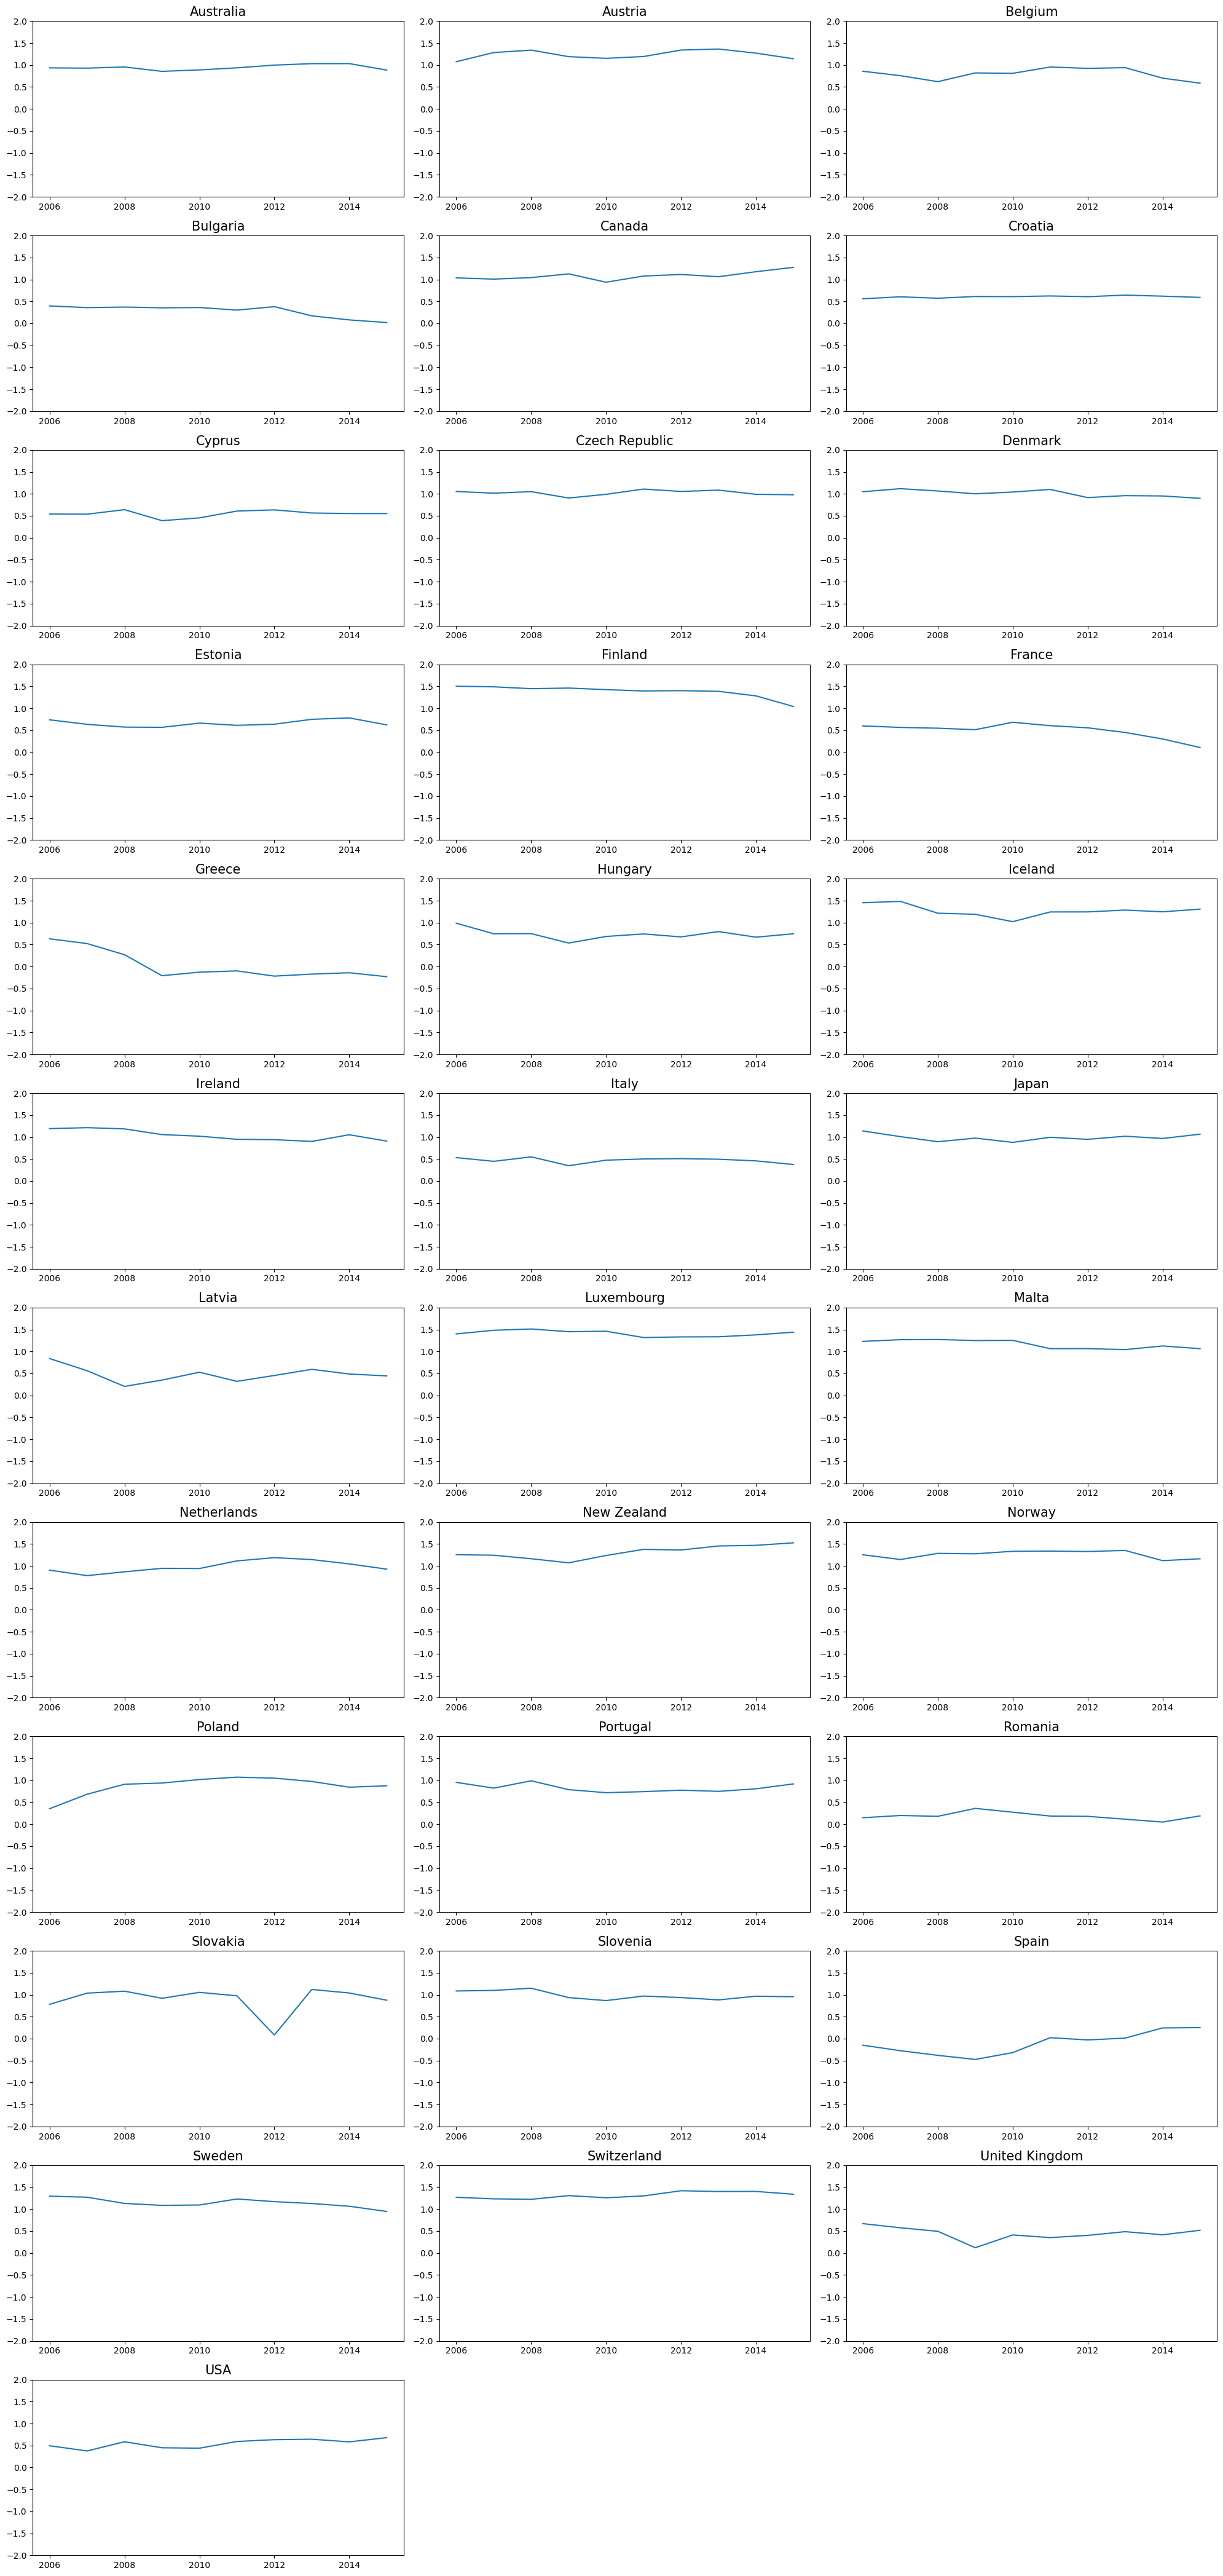

In [3]:
n_countries = dta['country'].nunique()

n_col = 3
height = 3.5

n_rows = math.ceil(n_countries / n_col)

fig, axes = plt.subplots(n_rows, n_col, figsize=(20, height * n_rows))
axes = axes.flatten()

for i, country in enumerate(dta['country'].unique()):
    country_data = dta[dta['country'] == country]
    axes[i].plot(country_data['year'], country_data['pol_stab'])
    axes[i].set_title(country, fontsize=15)
    axes[i].set_ylim(-2, 2)

for i in range(n_countries, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Кроме этого, для оценки межстрановых различий (отличаются ли страны в распределении зависимой переменной) построим "ящики с усами". Дополнительно при рассмотрении каждого отдельного графика мы также можем оценить внутристрановые изменения политической стабильности (то есть, изменения во времени)

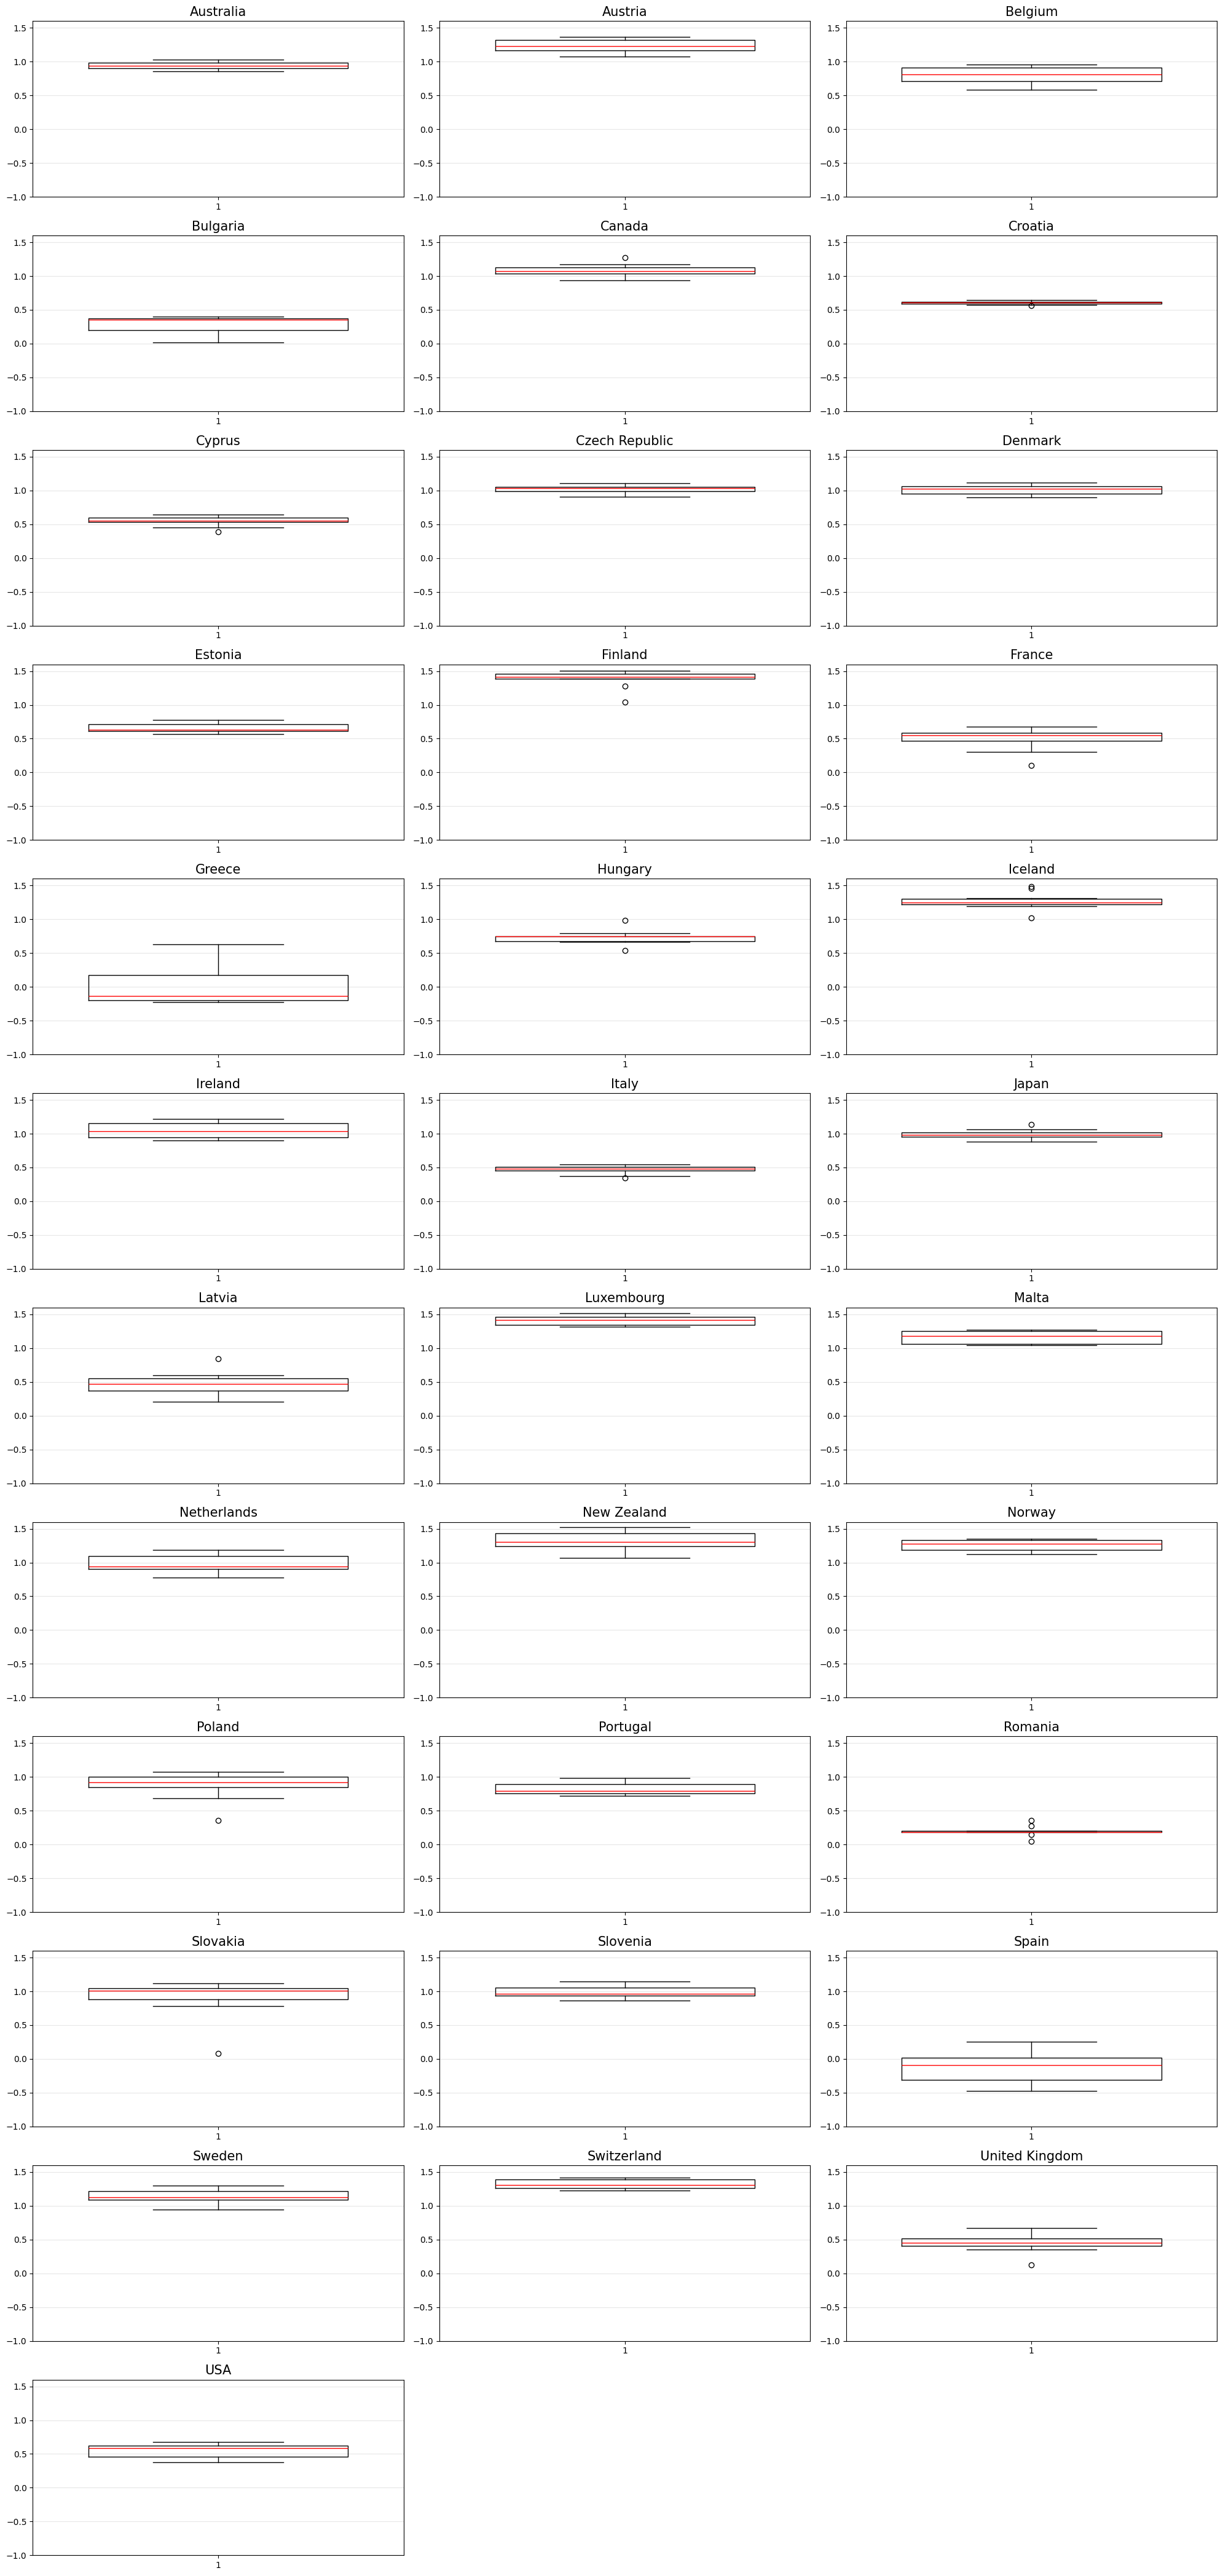

In [4]:
fig, axes = plt.subplots(n_rows, n_col, figsize=(20,  height * n_rows))
axes = axes.flatten()

for i, country in enumerate(dta['country'].unique()):
    country_data = dta[dta['country'] == country]['pol_stab']

    axes[i].boxplot(country_data, widths=0.7, medianprops={'color': 'red'})
    axes[i].set_title(country, fontsize=15)
    axes[i].set_ylim(-1, 1.6)
    axes[i].grid(True, alpha=0.3, axis='y')

for i in range(n_countries, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Посмотрим пример оценивания динамической регрессионной модели. Для начала рассмотрим модель с конечно-распределенным лагом на предиктор (FDL-модель). Стоит помнить, что такая модель пока еще не решает проблему автокорреляции. Тем не менее, если у Вас есть гипотеза об отложенном эффекте объясняющей переменной, такая модель может проверить такое предположение  

Предположим, что мы хотим отследить отложенный эффект коррупции, тогда нам нужно будет добавить соответствующую лагированную переменную в модель. Создадим подобную переменную с лагом в один, два и три года. Не забывайте о том, что наши данные сгруппированы по странам, поэтому сдвигаем мы ряд наблюдений внутри каждой единицы анализа, а не целый ряд сразу

In [5]:
dta_index = dta.set_index(['country', 'year'])

In [6]:
for lag in range(1, 4):
    dta_index[f'con_cor_lag{lag}'] = dta_index.groupby('country')['con_cor'].shift(lag)

dta_index

pol_stab   con_cor  herfgov_DPI  govt_consump_WDI  \
country   year                                                      
Australia 2006  0.935188  1.960568      0.75987         17.288634   
          2007  0.928790  2.010918      0.75987         17.175808   
          2008  0.955645  2.042482      1.00000         17.096951   
          2009  0.855689  2.051661      1.00000         17.496081   
          2010  0.888860  2.031455      1.00000         17.959095   
...                  ...       ...          ...               ...   
USA       2011  0.591247  1.269101      1.00000         16.309273   
          2012  0.632442  1.410720      1.00000         15.748125   
          2013  0.643073  1.313262      1.00000         15.119812   
          2014  0.582420  1.376068      1.00000         14.704415   
          2015  0.678062  1.396919      1.00000         14.442312   

                countrygroup  con_cor_lag1  con_cor_lag2  con_cor_lag3  
country   year                                                          
Australia 2006           1.0           NaN           NaN           NaN  
          2007           1.0      1.960568           NaN           NaN  
          2008           1.0      2.010918      1.960568           NaN  
          2009           1.0      2.042482      2.010918      1.960568  
          2010           1.0      2.051661      2.042482      2.010918  
...                      ...           ...           ...           ...  
USA       2011           1.0      1.271479      1.294352      1.450212  
          2012           1.0      1.269101      1.271479      1.294352  
          2013           1.0      1.410720      1.269101      1.271479  
          2014           1.0      1.313262      1.410720      1.269101  
          2015           1.0      1.376068      1.313262      1.410720  

[339 rows x 8 columns]

Оценим модель с фиксированными эффектами для учета неоднородности стран, добавив лагированный показатель коррупции  для проверки гипотезы об отложенном эффекте (то есть, модель с конечно-распределенным лагом - FDL-модель)

In [7]:
model1 = PanelOLS.from_formula(formula = 'pol_stab ~ con_cor + con_cor_lag1 + govt_consump_WDI + herfgov_DPI + EntityEffects', data = dta_index).fit(cov_type="clustered", cluster_entity=True)
print(model1)

/usr/local/lib/python3.12/dist-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


                          PanelOLS Estimation Summary                           
Dep. Variable:               pol_stab   R-squared:                        0.0587
Estimator:                   PanelOLS   R-squared (Between):             -0.0353
No. Observations:                 305   R-squared (Within):               0.0587
Date:                Sun, Apr 05 2026   R-squared (Overall):             -0.0331
Time:                        21:09:25   Log-likelihood                    215.52
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.1615
Entities:                          34   P-value                           0.0028
Avg Obs:                       8.9706   Distribution:                   F(4,267)
Min Obs:                       8.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             0.9468
                            

In [8]:
model2 = PanelOLS.from_formula(formula = 'pol_stab ~ con_cor + con_cor_lag1 + con_cor_lag2 + con_cor_lag3 + govt_consump_WDI + herfgov_DPI + EntityEffects', data = dta_index).fit(cov_type="clustered", cluster_entity=True)
print(model2)

                          PanelOLS Estimation Summary                           
Dep. Variable:               pol_stab   R-squared:                        0.0836
Estimator:                   PanelOLS   R-squared (Between):             -0.6898
No. Observations:                 237   R-squared (Within):               0.0836
Date:                Sun, Apr 05 2026   R-squared (Overall):             -0.6779
Time:                        21:09:26   Log-likelihood                    191.06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.9971
Entities:                          34   P-value                           0.0080
Avg Obs:                       6.9706   Distribution:                   F(6,197)
Min Obs:                       6.0000                                           
Max Obs:                       7.0000   F-statistic (robust):             1.3772
                            

/usr/local/lib/python3.12/dist-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


Другая мотивация для включения лагированных переменных в модель заключается в том, чтобы в явном виде смоделировать обнаруженную автокорреляцию остатков. В данном случае нам понадобится уже лагированная зависимая переменная.   

Прежде чем оценивать модели  с лагом на зависимую переменную, нам нужно проверить данные на стационарность. Те модели, которые мы планируем оценить, применимы к стационарным данным, то есть, в условии отсутствия значимых различий в характеристиках данных с течением времени (преполагаем постоянное среднее значение, дисперсию и ковариацию в условиях зафиксированного лага).

Для проверки применим тест Дики-Фуллера. Нулевая гипотеза в этом тесте: временной ряд является нестационарным

Наши результаты свидетельствуют о стационарности

In [9]:
model_auxiliary = statf.ols(formula = 'pol_stab ~ C(country)', data = dta).fit()
model_auxiliary_res = model_auxiliary.resid

adfuller_pol_stab = adfuller(model_auxiliary_res)

print('Augmented Dickey_Fuller Statistic: %f' % adfuller_pol_stab[0])
print('p-value: %f' % adfuller_pol_stab[1])

Augmented Dickey_Fuller Statistic: -9.111605
p-value: 0.000000


In [10]:
predictors = ['con_cor', 'govt_consump_WDI', 'herfgov_DPI']

for i, var in enumerate(predictors):
  m_resid = statf.ols(formula = f'{var} ~ C(country)', data = dta).fit().resid
  statistic = adfuller(m_resid)[0]
  p_value = adfuller(m_resid)[1]
  print(f"{var}: statistic = {statistic:.3f}, p-value = {p_value:.3f}")

con_cor: statistic = -9.386, p-value = 0.000
govt_consump_WDI: statistic = -7.137, p-value = 0.000
herfgov_DPI: statistic = -11.058, p-value = 0.000


Как мы видим, полученные p-value свидетельствуют в пользу отвержения нулевой гипотезы, значит данные можно считать стационарными

Проверим, есть ли автокорреляция в нашем случае. Для начала построим графики ACF и PACF:

In [11]:
model3 = statf.ols(formula = 'pol_stab ~ con_cor + govt_consump_WDI + herfgov_DPI + C(country)', data = dta).fit()

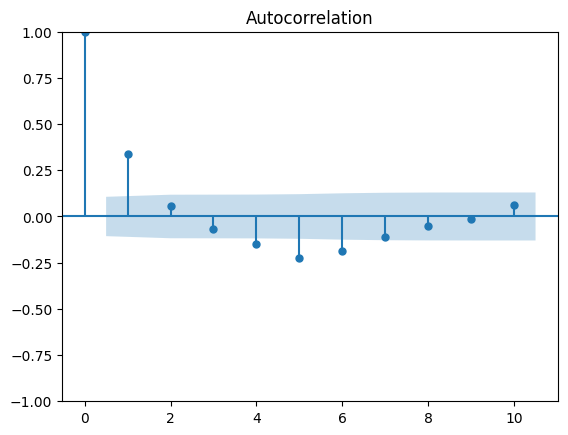

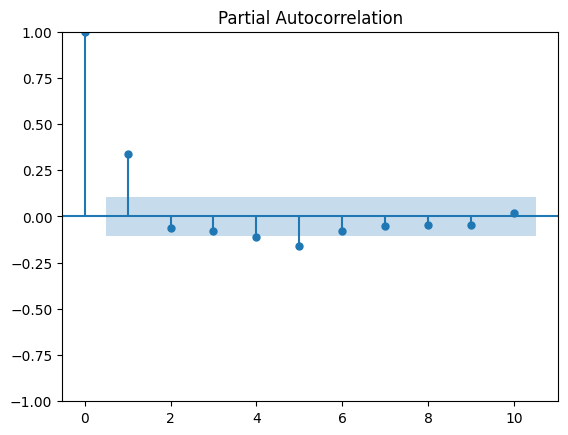

In [12]:
fig = tsaplots.plot_acf(model3.resid, lags=10)
plt.show()

fig = tsaplots.plot_pacf(model3.resid, lags=10)
plt.show()

И приведем результаты формального теста Бреуша-Годфри на автокорреляцию. Проверим автокорреляцию первого порядка, прописав в коде nlags = 1

In [13]:
bg_test = dg.acorr_breusch_godfrey(model3, nlags=1)

print(f"  Statistic: {bg_test[0]:.3f}")
print(f"  p-value: {bg_test[1]:.3f}")

  Statistic: 39.563
  p-value: 0.000


Оценим модель с лагированной зависимой переменной в качестве одного из предикторов (LDV-модель)

Здесь не стоит забывать о смещении Никеля (Nickell bias), которое заключается в том, что когда мы в модель с лагированной зависимой переменной добавляем фиксированные эффекты, то получаем смещение оценок коэффициентов. Однако с ростом количества временных периодов это смещение становится меньше

In [14]:
dta_index['pol_stab_lag1'] = dta_index.groupby(['country'])['pol_stab'].shift(1)

model4 = PanelOLS.from_formula(formula = 'pol_stab ~ con_cor + pol_stab_lag1 + govt_consump_WDI + herfgov_DPI + EntityEffects', data = dta_index).fit(cov_type='clustered', cluster_entity=True)
print(model4)

                          PanelOLS Estimation Summary                           
Dep. Variable:               pol_stab   R-squared:                        0.2098
Estimator:                   PanelOLS   R-squared (Between):              0.5764
No. Observations:                 305   R-squared (Within):               0.2098
Date:                Sun, Apr 05 2026   R-squared (Overall):              0.5702
Time:                        21:09:29   Log-likelihood                    242.22
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      17.726
Entities:                          34   P-value                           0.0000
Avg Obs:                       8.9706   Distribution:                   F(4,267)
Min Obs:                       8.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             14.935
                            

/usr/local/lib/python3.12/dist-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


Не забывайте снова применить тест Бреуша-Годфри уже после оценивания модели:

In [15]:
dta['pol_stab_lag1'] = dta.groupby(['country'])['pol_stab'].shift(1)
model4_1 = statf.ols(formula = 'pol_stab ~ con_cor + pol_stab_lag1 + govt_consump_WDI + herfgov_DPI + C(country)', data = dta).fit()

print('Breusch-Godfrey Test Statistic: %f' % dg.acorr_breusch_godfrey(model4_1, nlags = 1)[0])
print('p-value: %f' % dg.acorr_breusch_godfrey(model4_1, nlags = 1)[1])

Breusch-Godfrey Test Statistic: 0.099599
p-value: 0.752311


Оценим модель с лагом как на зависимую переменную, так и на предиктор (con_cor), то есть, модель ADL. Функция IRF для этой модели показывает "вспышку" эффекта предиктора, а далее этот эффект уже затухает

In [16]:
model5 = PanelOLS.from_formula(formula = 'pol_stab ~ con_cor + con_cor_lag1 + pol_stab_lag1 + govt_consump_WDI + herfgov_DPI + EntityEffects', data = dta_index).fit(cov_type='clustered', cluster_entity=True)
print(model5)

                          PanelOLS Estimation Summary                           
Dep. Variable:               pol_stab   R-squared:                        0.2469
Estimator:                   PanelOLS   R-squared (Between):              0.5128
No. Observations:                 305   R-squared (Within):               0.2469
Date:                Sun, Apr 05 2026   R-squared (Overall):              0.5082
Time:                        21:09:29   Log-likelihood                    249.54
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      17.440
Entities:                          34   P-value                           0.0000
Avg Obs:                       8.9706   Distribution:                   F(5,266)
Min Obs:                       8.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             14.828
                            

/usr/local/lib/python3.12/dist-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


В качестве альтернативной формы представления ADL модели можно рассматривать Error Correction Model (ECM). Для ее оценивания нам предварительно надо создать первые разности для отклика и ключевого предиктора (con_cor)

In [17]:
dta_index['con_cor_dif'] = dta_index.groupby(['country'])['con_cor'].diff()
dta_index.head(20)

pol_stab   con_cor  herfgov_DPI  govt_consump_WDI  \
country   year                                                      
Australia 2006  0.935188  1.960568     0.759870         17.288634   
          2007  0.928790  2.010918     0.759870         17.175808   
          2008  0.955645  2.042482     1.000000         17.096951   
          2009  0.855689  2.051661     1.000000         17.496081   
          2010  0.888860  2.031455     1.000000         17.959095   
          2011  0.935710  2.044637     1.000000         17.809681   
          2012  0.997997  1.985774     1.000000         18.038075   
          2013  1.031073  1.785322     1.000000         17.991869   
          2014  1.032192  1.853449     0.494321         17.841217   
          2015  0.884980  1.882090     0.494321         17.963135   
Austria   2006  1.075933  1.914531     0.719889         19.148688   
          2007  1.283752  2.013397     0.500111         18.665301   
          2008  1.339206  1.843035     0.500111         19.184111   
          2009  1.190602  1.703025     0.501543         20.577210   
          2010  1.152648  1.585462     0.501543         20.381193   
          2011  1.193522  1.431896     0.501543         19.781024   
          2012  1.340567  1.389731     0.501543         19.759504   
          2013  1.364101  1.550795     0.501543         19.792213   
          2014  1.270700  1.474735     0.501275         19.770560   
          2015  1.143079  1.519258     0.501275         19.922648   

                countrygroup  con_cor_lag1  con_cor_lag2  con_cor_lag3  \
country   year                                                           
Australia 2006           1.0           NaN           NaN           NaN   
          2007           1.0      1.960568           NaN           NaN   
          2008           1.0      2.010918      1.960568           NaN   
          2009           1.0      2.042482      2.010918      1.960568   
          2010           1.0      2.051661      2.042482      2.010918   
          2011           1.0      2.031455      2.051661      2.042482   
          2012           1.0      2.044637      2.031455      2.051661   
          2013           1.0      1.985774      2.044637      2.031455   
          2014           1.0      1.785322      1.985774      2.044637   
          2015           1.0      1.853449      1.785322      1.985774   
Austria   2006           3.0           NaN           NaN           NaN   
          2007           3.0      1.914531           NaN           NaN   
          2008           3.0      2.013397      1.914531           NaN   
          2009           3.0      1.843035      2.013397      1.914531   
          2010           3.0      1.703025      1.843035      2.013397   
          2011           3.0      1.585462      1.703025      1.843035   
          2012           3.0      1.431896      1.585462      1.703025   
          2013           3.0      1.389731      1.431896      1.585462   
          2014           3.0      1.550795      1.389731      1.431896   
          2015           3.0      1.474735      1.550795      1.389731   

                pol_stab_lag1  con_cor_dif  
country   year                              
Australia 2006            NaN          NaN  
          2007       0.935188     0.050350  
          2008       0.928790     0.031564  
          2009       0.955645     0.009179  
          2010       0.855689    -0.020206  
          2011       0.888860     0.013182  
          2012       0.935710    -0.058863  
          2013       0.997997    -0.200452  
          2014       1.031073     0.068127  
          2015       1.032192     0.028641  
Austria   2006            NaN          NaN  
          2007       1.075933     0.098866  
          2008       1.283752    -0.170362  
          2009       1.339206    -0.140010  
          2010       1.190602    -0.117563  
          2011       1.152648    -0.153566  
          2012       1.193522    -0.042165  
          201

In [18]:
dta_index['pol_stab_dif'] = dta_index.groupby(['country'])['pol_stab'].diff()

In [19]:
model5_ECM = PanelOLS.from_formula(formula = 'pol_stab_dif ~ con_cor_dif + con_cor_lag1 + pol_stab_lag1 + govt_consump_WDI + herfgov_DPI + EntityEffects', data = dta_index).fit(cov_type='clustered', cluster_entity=True)
print(model5_ECM)

                          PanelOLS Estimation Summary                           
Dep. Variable:           pol_stab_dif   R-squared:                        0.3628
Estimator:                   PanelOLS   R-squared (Between):             -428.88
No. Observations:                 305   R-squared (Within):               0.3628
Date:                Sun, Apr 05 2026   R-squared (Overall):             -21.376
Time:                        21:09:30   Log-likelihood                    249.54
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      30.285
Entities:                          34   P-value                           0.0000
Avg Obs:                       8.9706   Distribution:                   F(5,266)
Min Obs:                       8.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             10.118
                            

/usr/local/lib/python3.12/dist-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
